In [2]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate shape factor based on aspect ratio and feretmin
def calculate_shape_factor(aspect_ratio, feretmin):
    # Example: Shape factor increases as aspect ratio approaches 1
    # Larger feretmin values bias shape factor toward round shapes
    if aspect_ratio > 1:
        aspect_ratio = 1 / aspect_ratio  # Normalize aspect ratio to be <= 1
    
    # Shape factor formula (adjust as needed)
    shape_factor = aspect_ratio + 0.1 * np.log(feretmin + 1)
    
    # Ensure shape factor is within a reasonable range
    shape_factor = np.clip(shape_factor, 0.5, 1.5)
    
    return shape_factor

# Function to calculate ellipsoidal volume
def calculate_volume(dim1, dim2, dim3):
    return (4 / 3) * np.pi * (dim1 * dim2 * dim3) / (2**3)

# Function to calculate cumulative volume distribution
def calculate_cumulative_volume(results_df, sieve_bins):
    # Group grains by true minimum dimension (sieve bins)
    results_df['sieve_bin'] = pd.cut(results_df['true_min_dim'], bins=sieve_bins, labels=False)
    
    # Calculate total volume for each bin
    bin_volumes = results_df.groupby('sieve_bin')['volume'].sum()
    
    # Calculate cumulative volume as a percentage
    cumulative_volume = bin_volumes.cumsum() / bin_volumes.sum()
    
    return cumulative_volume

# Function to calculate aspect ratio
def calculate_aspect_ratio(dim1, dim2):
    return dim1 / dim2

# Function to assign aspect ratio bin
def assign_aspect_ratio_bin(aspect_ratio, bins):
    for i, (lower, upper) in enumerate(bins):
        if lower <= aspect_ratio < upper:
            return i
    return None  # If aspect ratio doesn't fit in any bin

# Function to derive realistic bounds for dim3
def derive_realistic_bounds(dim1, dim2, population_data, aspect_ratio_bin):
    # Filter population data for the given aspect ratio bin
    filtered_data = population_data[population_data['aspect_ratio_bin'] == aspect_ratio_bin]
    
    # Further filter for grains with similar dim1 and dim2 values
    filtered_data = filtered_data[
        (filtered_data['feret_min_mm'] <= dim1) & (filtered_data['feret_max_mm'] >= dim2)
    ]
    
    # Debugging: Check if filtered_data is empty
    if filtered_data.empty:
        print(f"Empty filtered data for dim1={dim1}, dim2={dim2}, aspect_ratio_bin={aspect_ratio_bin}")
    
    # Calculate realistic bounds for dim3
    lower_bound = filtered_data['feret_min_mm'].min()
    upper_bound = filtered_data['feret_max_mm'].max()
    
    # Debugging: Print bounds
    # print(f"Bounds for dim1={dim1}, dim2={dim2}: lower_bound={lower_bound}, upper_bound={upper_bound}")
    
    return lower_bound, upper_bound

# Function to estimate dim3 using modified ellipsoidal volume model
def estimate_dim3_with_shape_factor(dim1, dim2, volume, shape_factor, lower_bound, upper_bound):
    # Estimate dim3 using modified ellipsoidal volume formula
    dim3 = (volume * (3 / (4 * np.pi)) * (2**3)) / (dim1 * dim2 * shape_factor)
    
    # Restrict dim3 to realistic bounds
    dim3 = np.clip(dim3, lower_bound, upper_bound)
    
    return dim3

def calc_results(bins, sieve_data, sieve_bins, cumulative_volume_sieve, results_df):
    
    sieve_data = pd.read_csv(sieve_data)
    # Calculate cumulative volume distribution
    cumulative_volume_estimated = calculate_cumulative_volume(results_df, bins)

    # Plot cumulative volume distributions
    plt.plot(bins[:-1], cumulative_volume_estimated, label='Estimated')
    plt.plot(sieve_bins, cumulative_volume_sieve, label='Sieve Analysis')
    plt.xlabel('Feretmin (mm)')
    plt.xscale('log')
    plt.xlim(0.05, 0.85)
    plt.ylabel('Percent Passing')
    plt.legend()
    plt.show()  
    return cumulative_volume_estimated

def calculate_spherical_volume(feretmin):
    """
    Calculate the volume of a sphere given the feretmin (diameter).
    """
    radius = feretmin / 2
    volume = (4 / 3) * np.pi * (radius**3)
    return volume

def estimate_dim3_with_spherical_model(dim1, dim2, volume, shape_factor, lower_bound, upper_bound):
    """
    Estimate dim3 using a spherical model for larger grains and an ellipsoidal model for smaller grains.
    """
    # Threshold for switching between spherical and ellipsoidal models
    spherical_threshold = 0.5  # Example: grains with feretmin > 0.5 mm are modeled as spheres
    
    if dim1 > spherical_threshold:
        # Use spherical model for larger grains
        dim3 = calculate_spherical_volume(dim1)
    else:
        # Use ellipsoidal model for smaller grains
        dim3 = (volume * (3 / (4 * np.pi)) * (2**3)) / (dim1 * dim2 * shape_factor)
    
    # Restrict dim3 to realistic bounds
    dim3 = np.clip(dim3, lower_bound, upper_bound)
    
    return dim3 

def calculate_shape_factor(aspect_ratio, feretmin):
    # Normalize aspect ratio to be <= 1
    if aspect_ratio > 1:
        aspect_ratio = 1 / aspect_ratio
    
    # Shape factor formula: bias toward round shapes for larger grains
    shape_factor = aspect_ratio + 0.3 * np.log(feretmin + 1)
    
    # Ensure shape factor is within a reasonable range
    shape_factor = np.clip(shape_factor, 0.5, 1.5)
    
    return shape_factor

def main(pop_data, bins):
    # Load population data (example: feretmin, feretmax, dim3, aspect ratio bin)
    population_data = pd.read_csv(pop_data)

    # Calculate aspect ratio for each grain and assign bins
    population_data['aspect_ratio'] = population_data['feret_min_mm'] / population_data['feret_max_mm']
    population_data['aspect_ratio_bin'] = population_data['aspect_ratio'].apply(
        lambda x: assign_aspect_ratio_bin(x, bins)
    )

    # Iterate over grains in the dataset
    results = []
    for index, grain in tqdm(population_data.iterrows()):
        dim1 = grain['feret_min_mm']
        dim2 = grain['feret_max_mm']
        volume = grain['ellip_volume']  # Example: volume from sieve analysis
        
        # Calculate aspect ratio and assign bin
        aspect_ratio = calculate_aspect_ratio(dim1, dim2)
        aspect_ratio_bin = assign_aspect_ratio_bin(aspect_ratio, bins)
        
        # Derive realistic bounds for dim3
        lower_bound, upper_bound = derive_realistic_bounds(dim1, dim2, population_data, aspect_ratio_bin)
        
        # Calculate shape factor based on aspect ratio and feretmin
        shape_factor = calculate_shape_factor(aspect_ratio, dim1)
        
        # Estimate dim3 using modified ellipsoidal volume model
        dim3_estimated = estimate_dim3_with_shape_factor(dim1, dim2, volume, shape_factor, lower_bound, upper_bound)
        
        # Calculate the true minimum dimension
        true_min_dim = min(dim1, dim2, dim3_estimated)
        
        # Calculate volume using estimated dimensions
        estimated_volume = calculate_volume(dim1, dim2, dim3_estimated)
        
        # Append results
        results.append({
            'dim1': dim1,
            'dim2': dim2,
            'dim3_estimated': dim3_estimated,
            'true_min_dim': true_min_dim,  # Store the true minimum dimension
            'volume': estimated_volume,
            'shape_factor': shape_factor
        })

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    return results_df

In [ ]:
bins = [(0.01, 0.075), (0.075, 0.105), (0.105, 0.15), (0.15, 0.25), (0.25, 0.425), (0.425, 0.85), (0.85,1)]

results_df = main('./save_annotations_df_Olivine.csv', bins)

bins_tested = [0.01, 0.075, 0.105, 0.15, 0.25, 0.425, 0.85]

# Load sieve analysis cumulative volume data
sieve_data = "/projects/OLIVINE/data/sieve_results/Olivine.csv"
sieve_bins =  [0.85, 0.425, 0.25, 0.15, 0.105, 0.075, 0.01]
sieve_bins_reversed = sieve_bins[::-1]
# cumulative_volume_sieve = sieve_data['percentage passing']
cumulative_volume_sieve = list(np.asarray([0.05, 0.26, 24.52, 59.58, 79.44, 92.95, 99.99]) / 100)


In [58]:
results_df

,dim1,dim2,dim3_estimated,true_min_dim,volume,shape_factor
0,0.025147,0.059998,0.059998,0.025147,0.000047,0.500000
1,0.029591,0.034522,0.034522,0.029591,0.000018,0.865891
2,0.029591,0.172612,0.172612,0.029591,0.000462,0.500000
3,0.034522,0.039454,0.039454,0.034522,0.000028,0.885182
4,0.034522,0.108499,0.108499,0.034522,0.000213,0.500000
...,...,...,...,...,...,...
22336,0.517836,0.581949,0.541757,0.517836,0.085483,1.015016
22337,0.537563,0.872923,0.872923,0.537563,0.214477,0.744879
22338,0.552358,0.823606,0.857201,0.552358,0.204184,0.802591
22339,0.601676,0.606608,0.601676,0.601676,0.114983,1.133185


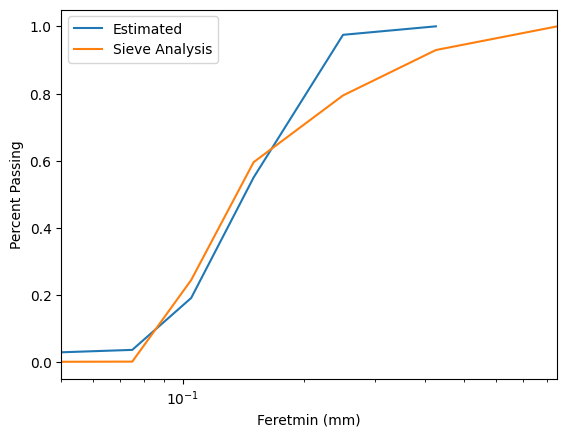

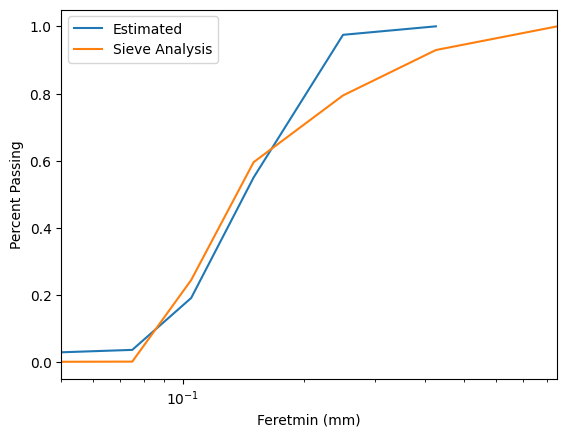

In [59]:

# Calculate cumulative volume distribution
cumulative_volume_estimated = calc_results(bins_tested, sieve_data, sieve_bins_reversed, cumulative_volume_sieve, results_df)

# Plot cumulative volume distributions
plt.plot(bins_tested[:-1], cumulative_volume_estimated, label='Estimated')  # Use bins_tested[:-1] for x-axis
plt.plot(sieve_bins_reversed, cumulative_volume_sieve, label='Sieve Analysis')  # Use sieve_bins_reversed for x-axis
plt.xlabel('Feretmin (mm)')
plt.xscale('log')
plt.xlim(0.05, 0.85)
plt.ylabel('Percent Passing')
plt.legend()
plt.show()

Percent Errors at Target Percent Passing Points:
Percent Passing 10%: 0.17%
Percent Passing 20%: 12.34%
Percent Passing 30%: 6.20%
Percent Passing 40%: 6.76%
Percent Passing 50%: 7.49%
Percent Passing 60%: 2.90%
Percent Passing 70%: 6.12%
Percent Passing 80%: 19.06%
Percent Passing 90%: 38.47%
Percent Passing 100%: 656.99%


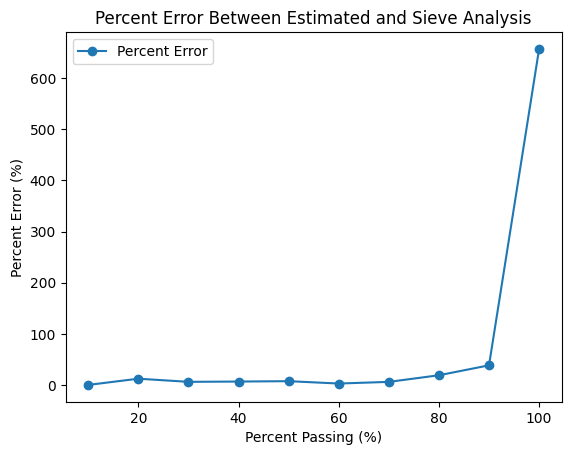

In [61]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

# Define target percent passing points (10%, 20%, ..., 100%)
target_percent_passing = np.linspace(0.1, 1.0, 10)

# Interpolate sieve analysis data (diameter vs. percent passing)
sieve_interp_func = interp1d(cumulative_volume_sieve, sieve_bins, kind='linear', fill_value="extrapolate")

# Interpolate estimated cumulative volume data (diameter vs. percent passing)
estimated_interp_func = interp1d(cumulative_volume_estimated, sieve_bins[:-1], kind='linear', fill_value="extrapolate")

# Get interpolated diameters at target percent passing points
sieve_diameters_at_target = sieve_interp_func(target_percent_passing)
estimated_diameters_at_target = estimated_interp_func(target_percent_passing)

# Calculate percent errors
percent_errors = [
    abs((estimated - sieve) / sieve) * 100
    for estimated, sieve in zip(estimated_diameters_at_target, sieve_diameters_at_target)
]

# Print percent errors
print("Percent Errors at Target Percent Passing Points:")
for i, error in enumerate(percent_errors):
    print(f"Percent Passing {target_percent_passing[i] * 100:.0f}%: {error:.2f}%")

# Plot percent errors
plt.plot(target_percent_passing * 100, percent_errors, marker='o', label='Percent Error')
plt.xlabel('Percent Passing (%)')
plt.ylabel('Percent Error (%)')
plt.title('Percent Error Between Estimated and Sieve Analysis')
plt.legend()
plt.show()


In [35]:
def derive_realistic_bounds(dim1, dim2, population_data):
    """
    Derive realistic bounds for dim3 based on grains with similar dim1 or dim2 values.
    """
    # Filter population data for grains with similar dim1 or dim2 values
    filtered_data = population_data[
        (population_data['feret_min_mm'] <= dim1 + 0.01) & (population_data['feret_min_mm'] >= dim1 - 0.01) |
        (population_data['feret_max_mm'] <= dim2 + 0.01) & (population_data['feret_max_mm'] >= dim2 - 0.01)
    ]
    
    # Handle empty filtered data
    if filtered_data.empty:
        print(f"Empty filtered data for dim1={dim1}, dim2={dim2}. Assigning default bounds.")
        return 0.01, 1.0  # Default bounds (adjust as needed)
    
    # Calculate realistic bounds for dim3 based on dim1 and dim2
    lower_bound = filtered_data['feret_min_mm'].min()
    upper_bound = filtered_data['feret_max_mm'].max()

    return lower_bound, upper_bound


def calculate_cumulative_volume(results_df, bins):
    # Group grains by true minimum dimension (sieve bins)
    results_df['sieve_bin'] = pd.cut(results_df['true_min_dim'], bins=bins, labels=False)
    
    # Calculate total volume for each bin
    bin_volumes = results_df.groupby('sieve_bin')['volume'].sum()
    
    # Ensure all bins are represented (fill missing bins with 0 volume)
    bin_volumes = bin_volumes.reindex(range(len(bins) - 1), fill_value=0)
    
    # Calculate cumulative volume as a percentage
    cumulative_volume = bin_volumes.cumsum() / bin_volumes.sum()
    
    return cumulative_volume

def error_compare(cumulative_volume_sieve, sieve_bins, cumulative_volume_estimated, bins_tested):
    # Define target percent passing points (10%, 20%, ..., 100%)
    target_percent_passing = np.linspace(0.1, 1.0, 10)

    # Interpolate sieve analysis data (diameter vs. percent passing)
    sieve_interp_func = interp1d(cumulative_volume_sieve, sieve_bins, kind='linear', fill_value="extrapolate")

    # Interpolate estimated cumulative volume data (diameter vs. percent passing)
    estimated_interp_func = interp1d(cumulative_volume_estimated, bins_tested[:-1], kind='linear', fill_value="extrapolate")

    # Get interpolated diameters at target percent passing points
    sieve_diameters_at_target = sieve_interp_func(target_percent_passing)
    estimated_diameters_at_target = estimated_interp_func(target_percent_passing)

    # Calculate percent errors
    percent_errors = [
        abs((estimated - sieve) / sieve) * 100
        for estimated, sieve in zip(estimated_diameters_at_target, sieve_diameters_at_target)
    ]

    # Print percent errors
    print("Percent Errors at Target Percent Passing Points:")
    for i, error in enumerate(percent_errors):
        print(f"Percent Passing {target_percent_passing[i] * 100:.0f}%: {error:.2f}%")

    # Plot percent errors
    plt.plot(target_percent_passing * 100, percent_errors, marker='o', label='Percent Error')
    plt.xlabel('Percent Passing (%)')
    plt.ylabel('Percent Error (%)')
    plt.title('Percent Error Between Estimated and Sieve Analysis')
    plt.legend()
    plt.show()

def main(pop_data, bins):
    # Load population data (example: feretmin, feretmax, dim3, aspect ratio bin)
    population_data = pd.read_csv(pop_data)

    # Iterate over grains in the dataset
    results = []
    for index, grain in tqdm(population_data.iterrows()):
        dim1 = grain['feret_min_mm']
        dim2 = grain['feret_max_mm']
        volume = grain['ellip_volume']  # Example: volume from sieve analysis
        
        # Derive realistic bounds for dim3
        lower_bound, upper_bound = derive_realistic_bounds(dim1, dim2, population_data)
        
        # Calculate aspect ratio and assign bin
        aspect_ratio = calculate_aspect_ratio(dim1, dim2)
        
        # Calculate shape factor based on aspect ratio and feretmin
        shape_factor = calculate_shape_factor(aspect_ratio, dim1)
        
        # Estimate dim3 using modified ellipsoidal volume model
        dim3_estimated = estimate_dim3_with_shape_factor(dim1, dim2, volume, shape_factor, lower_bound, upper_bound)
        
        # Calculate the true minimum dimension
        true_min_dim = min(dim1, dim2)
        
        # Calculate volume using estimated dimensions
        estimated_volume = calculate_volume(dim1, dim2, dim1)
        
        # Append results
        results.append({
            'dim1': dim1,
            'dim2': dim2,
            'dim3_estimated': dim3_estimated,
            'true_min_dim': true_min_dim,
            'volume': estimated_volume,
            'shape_factor': shape_factor
        })

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)

    return results_df

In [14]:
bins = [(0.01, 0.075), (0.075, 0.105), (0.105, 0.15), (0.15, 0.25), (0.25, 0.425), (0.425, 0.85)]

results_df = main('./save_annotations_df_Olivine.csv', bins)

bins_tested = [0.01, 0.075, 0.105, 0.15, 0.25, 0.425, 0.85, 1.5]

# Load sieve analysis cumulative volume data
sieve_data = "/projects/OLIVINE/data/sieve_results/Olivine.csv"
sieve_bins =  [0.85, 0.425, 0.25, 0.15, 0.105, 0.075, 0.01]
sieve_bins_reversed = sieve_bins[::-1]
# cumulative_volume_sieve = sieve_data['percentage passing']
cumulative_volume_sieve = list(np.asarray([0.05, 0.26, 24.52, 59.58, 79.44, 92.95, 99.99]) / 100)


22341it [00:21, 1030.83it/s]


In [17]:
bins_tested = [0.01, 0.075, 0.105, 0.15, 0.25, 0.425, 0.85, 1]


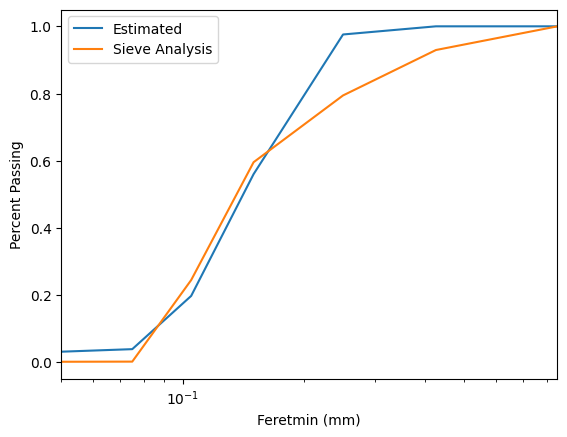

In [18]:
# Calculate cumulative volume distribution
cumulative_volume_estimated = calc_results(bins_tested, sieve_data, sieve_bins_reversed, cumulative_volume_sieve, results_df)


Percent Errors at Target Percent Passing Points:
Percent Passing 10%: 0.71%
Percent Passing 20%: 5.87%
Percent Passing 30%: 5.03%
Percent Passing 40%: 4.17%
Percent Passing 50%: 3.48%
Percent Passing 60%: 4.88%
Percent Passing 70%: 9.31%
Percent Passing 80%: 19.27%
Percent Passing 90%: 40.08%
Percent Passing 100%: 50.04%


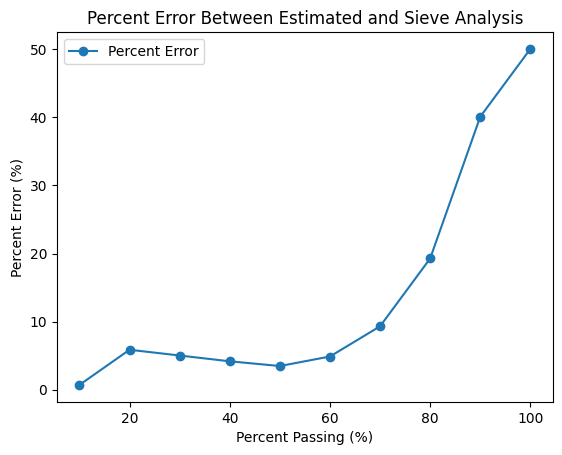

In [19]:
error_compare(cumulative_volume_sieve, sieve_bins_reversed, cumulative_volume_estimated, bins_tested)


In [4]:
bins = [(0.01, 0.075), (0.075, 0.105), (0.105, 0.15), (0.15, 0.25), (0.25, 0.425), (0.425, 0.85), (0.85, 2)]

results_df = main('/projects/OLIVINE/data/output/PARTICLE/Amodal/oryx/model_B/venice_all_36fps_3_0.2/save_annotations_df_Venice_Beach.csv', bins)

58022it [01:04, 905.38it/s] 


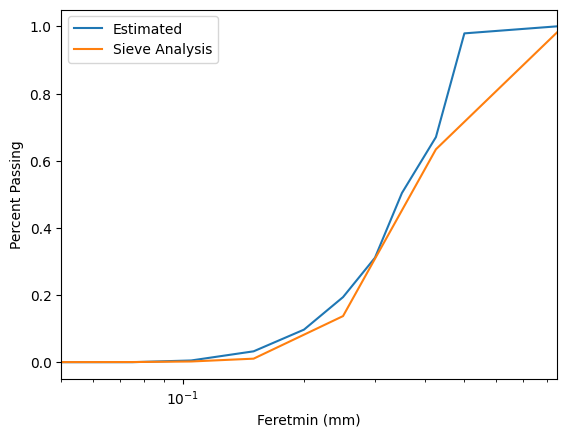

In [12]:
# Load sieve analysis cumulative volume data
sieve_data = "/projects/OLIVINE/data/sieve_results/Venice_Beach.csv"
sieve_bins =  [0.01, 0.075, 0.105, 0.15, 0.25, 0.425, 0.85]
# cumulative_volume_sieve = sieve_data['percentage passing']
cumulative_volume_sieve = list(np.asarray([0, 0.0818, 0.249, 1.09, 13.76, 63.4, 98.26]) / 100)

bins_tested = [0.01, 0.075, 0.105, 0.15, 0.2, 0.25, 0.3, 0.35, 0.425, 0.5, 0.85, 2]

# Calculate cumulative volume distribution
cumulative_volume_estimated = calc_results(bins_tested, sieve_data, sieve_bins, cumulative_volume_sieve, results_df)

Percent Errors at Target Percent Passing Points:
Percent Passing 10%: 31.61%
Percent Passing 20%: 35.57%
Percent Passing 30%: 34.96%
Percent Passing 40%: 34.47%
Percent Passing 50%: 34.08%
Percent Passing 60%: 30.90%
Percent Passing 70%: 36.25%
Percent Passing 80%: 42.77%
Percent Passing 90%: 47.17%
Percent Passing 100%: 2.43%


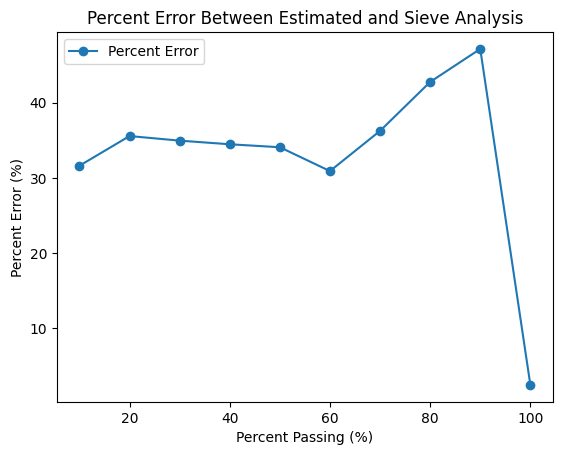

In [8]:
error_compare(cumulative_volume_sieve, sieve_bins, cumulative_volume_estimated, bins_tested)

In [36]:
bins = [(0.01, 0.075), (0.075, 0.105), (0.105, 0.15), (0.15, 0.25), (0.25, 0.425), (0.425, 0.85), (0.85, 2)]

results_df = main('/projects/OLIVINE/data/output/PARTICLE/Amodal/oryx/model_olivine/olivine_all_36fps_0.2/save_annotations_df_Olivine.csv', bins)

0it [00:00, ?it/s]/scratch/ipykernel_2683281/1628356038.py:79: RuntimeWarning: invalid value encountered in scalar divide
  dim3 = (volume * (3 / (4 * np.pi)) * (2**3)) / (dim1 * dim2 * shape_factor)
34910it [00:37, 924.92it/s] 


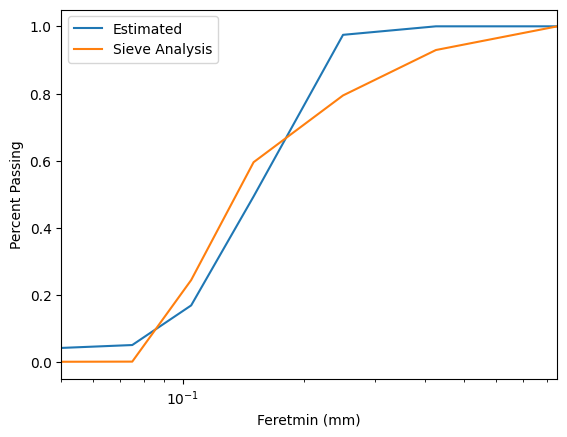

In [51]:
bins_tested = [0.01, 0.075, 0.105, 0.15, 0.25, 0.425, 0.85, 1]

# Load sieve analysis cumulative volume data
sieve_data = "/projects/OLIVINE/data/sieve_results/Olivine.csv"
sieve_bins =  [0.85, 0.425, 0.25, 0.15, 0.105, 0.075, 0.01]
sieve_bins_reversed = sieve_bins[::-1]
# cumulative_volume_sieve = sieve_data['percentage passing']
cumulative_volume_sieve = list(np.asarray([0.05, 0.26, 24.52, 59.58, 79.44, 92.95, 99.99]) / 100)

# Calculate cumulative volume distribution
cumulative_volume_estimated = calc_results(bins_tested, sieve_data, sieve_bins_reversed, cumulative_volume_sieve, results_df)

Percent Errors at Target Percent Passing Points:
Percent Passing 10%: 0.22%
Percent Passing 20%: 9.84%
Percent Passing 30%: 9.85%
Percent Passing 40%: 9.68%
Percent Passing 50%: 9.84%
Percent Passing 60%: 13.11%
Percent Passing 70%: 4.75%
Percent Passing 80%: 16.95%
Percent Passing 90%: 39.38%
Percent Passing 100%: 50.04%


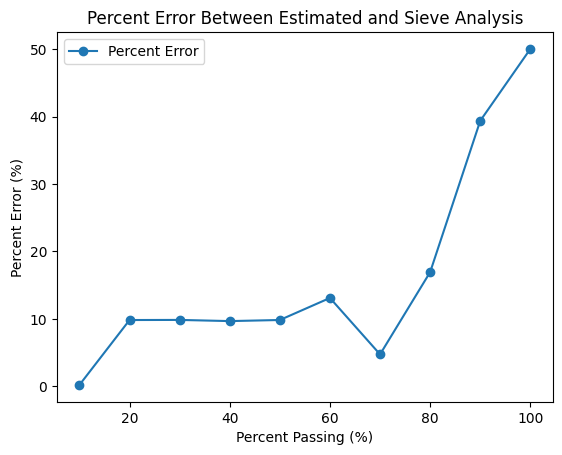

In [38]:
error_compare(cumulative_volume_sieve, sieve_bins_reversed, cumulative_volume_estimated, bins_tested)

(array([1.510e+02, 6.690e+02, 3.092e+03, 6.600e+03, 6.897e+03, 5.120e+03,
        3.379e+03, 2.309e+03, 1.684e+03, 1.304e+03, 1.066e+03, 8.610e+02,
        6.580e+02, 4.620e+02, 3.200e+02, 1.520e+02, 1.060e+02, 4.000e+01,
        2.200e+01, 1.000e+01, 2.000e+00, 4.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([0.        , 0.02433007, 0.04866013, 0.0729902 , 0.09732026,
        0.12165033, 0.14598039, 0.17031046, 0.19464052, 0.21897059,
        0.24330065, 0.26763072, 0.29196078, 0.31629085, 0.34062091,
        0.36495098, 0.38928105, 0.41361111, 0.43794118, 0.46227124,
        0.48660131, 0.51093137, 0.53526144, 0.5595915 , 0.58392157,
        0.60825163, 0.6325817 , 0.65691176, 0.68124183, 0.70557189,
        0.72990196]),
 <BarContainer object of 30 artists>)

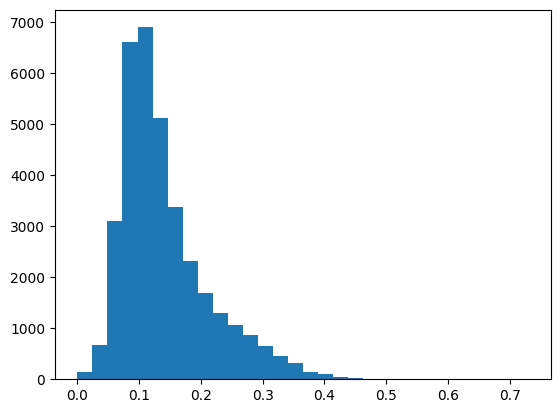

In [40]:
plt.hist(results_df['true_min_dim'], bins=30)